## 1. Kaggle API Setup

**Purpose:** Configure Kaggle API credentials to enable dataset downloads.

**What it does:**

- Creates `.kaggle` directory in the user's home folder
- Copies the `kaggle.json` authentication file to the correct location
- Sets proper file permissions (read/write for owner only) for security
- Verifies that the credentials file exists

**Requirements:** You must have a `kaggle.json` file with your API credentials from Kaggle.com.


In [2]:
# Create the .kaggle folder (if not present) **inside this notebook runtime**:
import os, pathlib, json, shutil, getpass

home = pathlib.Path.home()
kag_dir = home / ".kaggle"
kag_dir.mkdir(exist_ok=True)

# If your kaggle.json is already on disk, copy it once.
# Change the source path below if you saved it elsewhere.
src = r"C:\Users\sahan\Desktop\MYProjects\Neonatal_jaundice_detection\.kaggle\kaggle.json"  
shutil.copy(src, kag_dir / "kaggle.json")

# Good hygiene:  read/write for you, nothing for others
os.chmod(kag_dir / "kaggle.json", 0o600)

# Verify the token file exists
print("kaggle.json present:", (kag_dir / "kaggle.json").exists())


kaggle.json present: True


## 2. Download and Extract Dataset

**Purpose:** Fetch the jaundice image dataset from Kaggle and prepare it for use.

**What it does:**

- Downloads the "jaundice-image-data" dataset using Kaggle CLI
- Saves the zip file to the `./data` directory
- Extracts all images from the zip archive
- Displays a preview of the directory structure showing folders and files
- Organizes images into Normal and Jaundice categories

**Output:** Extracted dataset ready for model training in the `data/` folder.


In [3]:
# 1) download data set
!kaggle datasets download -d aiolapo/jaundice-image-data -p ./data -q

# 2) extract with Python's standard library
import zipfile, pathlib, os, itertools

zip_path = pathlib.Path("data") / "jaundice-image-data.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("data")

# 3) quick directory peek – show first few sub-folders/files
def tree_preview(root="data", max_lines=20):
    lines_shown = 0
    for dirpath, dirnames, filenames in os.walk(root):
        indent = " " * (dirpath.replace(root, "").count(os.sep) * 2)
        print(f"{indent}{pathlib.Path(dirpath).name}/")
        lines_shown += 1
        for f in filenames[:5]:
            print(f"{indent}  {f}")
            lines_shown += 1
        if lines_shown >= max_lines:
            return
tree_preview()


'kaggle' is not recognized as an internal or external command,
operable program or batch file.


data/
  jaundice-image-data.zip
  jaundice/
    jaundice (1).jpg
    jaundice (10).jpg
    jaundice (100).jpg
    jaundice (101).jpg
    jaundice (102).jpg
  normal/
    jaundice.jpg
    normal (1).jpg
    normal (1000).jpg
    normal (1001).jpg
    normal (1002).jpg


## 3. Exploratory Data Analysis (EDA)

**Purpose:** Understand the dataset composition and visualize sample images.

**What it does:**

- Counts the number of images in each class (Normal vs Jaundice)
- Randomly selects 4 sample images from the dataset
- Displays the samples in a 2×2 grid with class labels
- Converts images from BGR to RGB color format for proper visualization

**Output:**

- Image count statistics per class
- Visual preview of random sample images to verify data quality


Normal: 561 images
Jaundice: 200 images


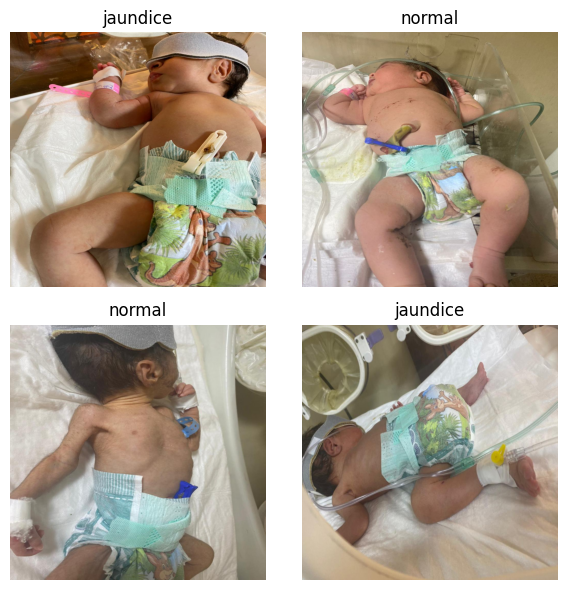

In [4]:

import cv2, random, matplotlib.pyplot as plt, pathlib

root = pathlib.Path("data")

# Count images
for cls in ("Normal","Jaundice"):
    n = len(list((root/cls).glob("*")))
    print(f"{cls}: {n} images")

# Peek at a few randomly chosen pictures
sample_files = random.sample(list(root.rglob("*.*")), 4)
plt.figure(figsize=(6,6))
for i,f in enumerate(sample_files,1):
    img = cv2.cvtColor(cv2.imread(str(f)), cv2.COLOR_BGR2RGB)
    plt.subplot(2,2,i); plt.imshow(img); plt.title(f.parent.name); plt.axis("off")
plt.tight_layout(); plt.show()


## 4. Image Preprocessing Constants

**Purpose:** Define standardized parameters for image preprocessing.

**What it does:**

- Sets image size to 224×224 pixels (MobileNetV3 input requirement)
- Defines ImageNet normalization constants:
  - **MEAN:** (0.485, 0.456, 0.406) - RGB channel means
  - **STD:** (0.229, 0.224, 0.225) - RGB channel standard deviations

**Why:** Using ImageNet normalization improves transfer learning performance when using pretrained models.


In [5]:
# Define image size and normalization constants
IMG_SIZE = 224
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

## 5. Custom Dataset Class with Dual Labels

**Purpose:** Create a PyTorch Dataset that provides both jaundice detection and image quality labels.

**What it does:**

- Implements `EyeJaundiceSet` custom dataset class
- Loads images from Normal/Jaundice folders
- Generates **two labels** per image:
  1. **Jaundice label:** 0 = Normal, 1 = Jaundice
  2. **Quality label:** 0 = Poor lighting (brightness < 35), 1 = Good quality
- Performs data preprocessing:
  - Resizes images to 224×224
  - Applies random horizontal flip for training augmentation
  - Normalizes using ImageNet mean/std
  - Converts to PyTorch tensor format (CHW)
- Splits data into train/validation sets (85%/15%)

**Output:** Dataset object ready for DataLoader integration.


In [6]:
from torch.utils.data import Dataset
import cv2, random, numpy as np, pathlib, torch

# Simple heuristic for lighting quality
BRIGHTNESS_THRESHOLD = 35.0  # same idea as in app.py

class EyeJaundiceSet(Dataset):
    def __init__(self, root="data", split="train", val_ratio=0.15, seed=42):
        root = pathlib.Path(root)
        items = []
        for label, cls in enumerate(("Normal", "Jaundice")):
            for p in (root / cls).glob("*"):
                items.append((str(p), label))  # Convert path to string

        random.Random(seed).shuffle(items)
        n_val = int(len(items) * val_ratio)
        self.items = items[n_val:] if split == "train" else items[:n_val]
        self.split = split

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, jaundice_label = self.items[idx]

        # Read image in BGR
        img_bgr = cv2.imread(path)
        if img_bgr is None:
            raise ValueError(f"Could not read image at {path}")

        # Compute brightness BEFORE normalization (0–255)
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        brightness = float(gray.mean())
        # Quality label: 1 = usable, 0 = too dark / poor quality
        quality_label = 0.0 if brightness < BRIGHTNESS_THRESHOLD else 1.0

        # Convert to RGB for model
        img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Resize
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Simple data augmentation for training
        if self.split == "train":
            if random.random() > 0.5:
                img = cv2.flip(img, 1)

        # Normalize and convert to tensor
        img = img.astype(np.float32) / 255.0
        for i in range(3):
            img[:, :, i] = (img[:, :, i] - MEAN[i]) / STD[i]

        # HWC to CHW format
        img = img.transpose(2, 0, 1)
        img_tensor = torch.FloatTensor(img)

        # Two targets: [jaundice_label, quality_label]
        target = torch.tensor([jaundice_label, quality_label], dtype=torch.float32)

        return img_tensor, target


## 6. Initialize Training and Validation Datasets

**Purpose:** Create separate dataset instances for training and validation.

**What it does:**

- Instantiates `train_ds` with split="train" (85% of data)
- Instantiates `val_ds` with split="val" (15% of data)
- Uses the same random seed (42) for reproducible splits
- Both datasets load from the `data/` directory

**Output:** Two dataset objects ready to be wrapped in DataLoaders for batch processing.


In [7]:

# Instantiate datasets for training and validation
train_ds = EyeJaundiceSet(root="data", split="train")
val_ds = EyeJaundiceSet(root="data", split="val")


## 7. Build Dual-Head MobileNetV3 Model

**Purpose:** Create a multi-task learning model that predicts both jaundice and image quality.

**What it does:**

- Uses **MobileNetV3-Small** as backbone (pretrained on ImageNet)
- Implements `JaundiceQualityModel` with:
  - **Shared backbone:** Feature extraction layers
  - **Jaundice head:** Binary classifier for jaundice detection
  - **Quality head:** Binary classifier for image quality assessment
- Configures training components:
  - **Loss functions:** Binary Cross-Entropy with Logits for both heads
  - **Optimizer:** AdamW with learning rate 1e-3
  - **Scheduler:** ReduceLROnPlateau (reduces LR when validation loss plateaus)
  - **Quality loss weight (λ):** 0.5 to balance both tasks
- Moves model to GPU if available, otherwise CPU

**Output:** Ready-to-train dual-head neural network model.


In [8]:
import torchvision.models as models
import torch.nn as nn, torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"

class JaundiceQualityModel(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        # Use MobileNetV3 backbone up to the last hidden layer
        self.backbone = nn.Sequential(
            base_model.features,
            base_model.avgpool,
            nn.Flatten(),
            base_model.classifier[0],  # Linear to 1024
            base_model.classifier[1],  # Hardswish
            base_model.classifier[2],  # Dropout
        )
        in_features = base_model.classifier[3].in_features

        # Two heads: one for jaundice, one for quality
        self.jaundice_head = nn.Linear(in_features, 1)
        self.quality_head = nn.Linear(in_features, 1)

    def forward(self, x):
        x = self.backbone(x)
        logits_j = self.jaundice_head(x)
        logits_q = self.quality_head(x)
        return logits_j, logits_q

base = models.mobilenet_v3_small(weights="MobileNet_V3_Small_Weights.DEFAULT")
model = JaundiceQualityModel(base).to(device)

criterion_j = nn.BCEWithLogitsLoss()
criterion_q = nn.BCEWithLogitsLoss()
lambda_q = 0.5  # how strongly to weight quality loss

optimizer = optim.AdamW(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.3)


## 8. Model Training with Early Stopping

**Purpose:** Train the dual-head model with monitoring and automatic early stopping.

**What it does:**

- **Setup:**
  - Creates DataLoaders for train/validation sets (batch size 32, num_workers=0 for Windows)
  - Installs tqdm for progress bars
- **Training Loop (up to 50 epochs):**
  - Forward pass through both heads (jaundice + quality)
  - Computes combined loss: `loss_j + 0.5 × loss_q`
  - Backpropagation and optimizer step
  - Tracks metrics: loss, accuracy, sensitivity, specificity (for jaundice only)
- **Validation:**
  - Evaluates on validation set without gradient computation
  - Updates learning rate scheduler based on validation loss
- **Early Stopping:**
  - Monitors validation loss
  - Stops if no improvement for 5 consecutive epochs
- **Artifacts Saved:**
  - Metrics CSV with epoch-wise statistics
  - Loss plot (train vs validation)
  - Performance plot (accuracy, sensitivity, specificity)

**Output:** Trained model with saved training metrics and visualization plots.


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\sahan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

00  train acc 0.785 | val acc 0.719  sens 0.000  spec 1.000


...

  0%|          | 0/4 [00:00<?, ?it/s]

30  train acc 1.000 | val acc 0.912  sens 0.844  spec 0.939


  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

31  train acc 1.000 | val acc 0.904  sens 0.812  spec 0.939
Early stopping at epoch 31 (no val loss improvement for 5 epochs)


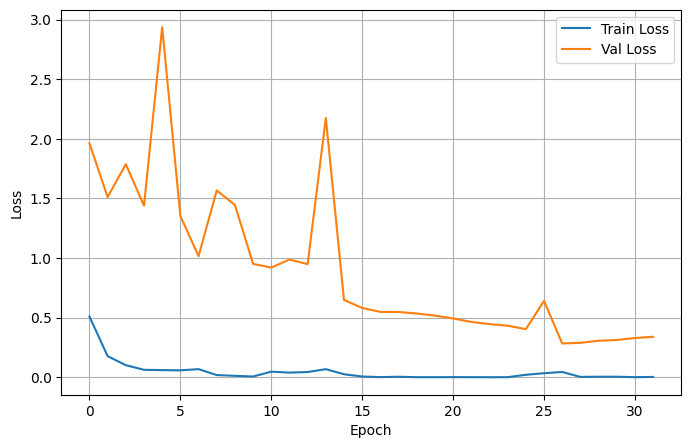

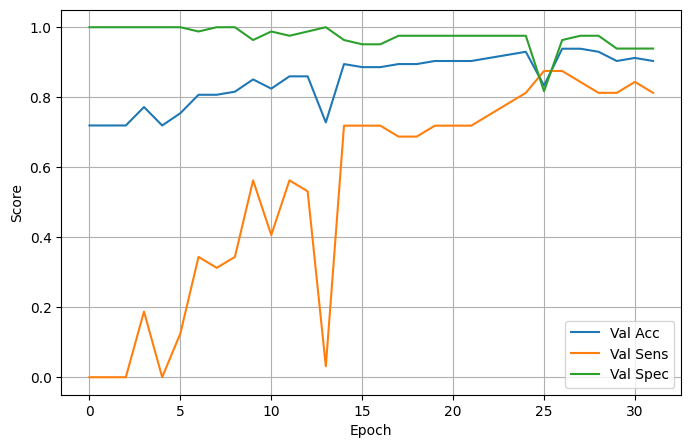

In [ ]:
# ------------------------------------------------------------------
# one-time install for a nicer progress bar (safe to re-run)
%pip install --user -q ipywidgets tqdm

from tqdm.auto import tqdm
from torch.utils.data import DataLoader

# ── REBUILD LOADERS WITH A SINGLE WORKER (Windows-safe) ───────────
train_dl = DataLoader(train_ds,
                      batch_size=32,
                      shuffle=True,
                      num_workers=0,     # <- THE KEY FIX
                      pin_memory=True)

val_dl = DataLoader(val_ds,
                    batch_size=32,
                    shuffle=False,
                    num_workers=0,
                    pin_memory=True)

# ── TRAIN / EVAL HELPER ───────────────────────────────────────────
def epoch_pass(dataloader, train=True):
    model.train(train)
    loss_sum = 0.0
    tp = tn = fp = fn = 0

    for x, y in tqdm(dataloader, leave=False):
        x = x.to(device)
        y = y.to(device)  # shape [B, 2]: [jaundice, quality]

        y_j = y[:, 0].unsqueeze(1)  # jaundice target
        y_q = y[:, 1].unsqueeze(1)  # quality target

        logits_j, logits_q = model(x)

        loss_j = criterion_j(logits_j, y_j)
        loss_q = criterion_q(logits_q, y_q)
        loss = loss_j + lambda_q * loss_q

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        loss_sum += loss.item() * len(x)

        # Metrics for jaundice only (binary)
        probs_j = torch.sigmoid(logits_j)
        preds = (probs_j > 0.5).int()

        tp += ((preds == 1) & (y_j == 1)).sum().item()
        tn += ((preds == 0) & (y_j == 0)).sum().item()
        fp += ((preds == 1) & (y_j == 0)).sum().item()
        fn += ((preds == 0) & (y_j == 1)).sum().item()

    n = len(dataloader.dataset)
    acc = (tp + tn) / n
    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    return loss_sum / n, acc, sens, spec


# MAIN TRAINING LOOP
EPOCHS = 50  # upper bound; early stopping will usually stop earlier
patience = 5  # epochs with no val-loss improvement before stopping
best_vl_loss = float("inf")
epochs_without_improvement = 0
metrics = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_sens": [],
    "val_spec": [],
}

for epoch in range(EPOCHS):
    tr_loss, tr_acc, *_ = epoch_pass(train_dl, train=True)
    vl_loss, vl_acc, vl_sens, vl_spec = epoch_pass(val_dl, train=False)

    metrics["epoch"].append(epoch)
    metrics["train_loss"].append(tr_loss)
    metrics["train_acc"].append(tr_acc)
    metrics["val_loss"].append(vl_loss)
    metrics["val_acc"].append(vl_acc)
    metrics["val_sens"].append(vl_sens)
    metrics["val_spec"].append(vl_spec)

    scheduler.step(vl_loss)

    if vl_loss < best_vl_loss - 1e-4:
        best_vl_loss = vl_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"{epoch:02d}  train acc {tr_acc:.3f} | "
        f"val acc {vl_acc:.3f}  sens {vl_sens:.3f}  spec {vl_spec:.3f}"
    )

    if epochs_without_improvement >= patience:
        print(
            f"Early stopping at epoch {epoch} "
            f"(no val loss improvement for {patience} epochs)"
        )
        break

# Save metrics and plots

from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt


output_dir = "training_metrics"
os.makedirs(output_dir, exist_ok=True)

import datetime
run_id = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

csv_path = os.path.join(output_dir, f"metrics_{run_id}.csv")
df = pd.DataFrame(metrics)
df.to_csv(csv_path, index=False)

# Plot and save loss curves

plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
plt.plot(df["epoch"], df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
loss_png = os.path.join(output_dir, f"loss_{run_id}.png")
plt.savefig(loss_png, bbox_inches="tight")
plt.show()

# Plot and save accuracy / sensitivity / specificity curves
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["val_acc"], label="Val Acc")
plt.plot(df["epoch"], df["val_sens"], label="Val Sens")
plt.plot(df["epoch"], df["val_spec"], label="Val Spec")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
metrics_png = os.path.join(output_dir, f"metrics_{run_id}.png")
plt.savefig(metrics_png, bbox_inches="tight")
plt.show()
# ------------------------------------------------------------------


## 9. Threshold Optimization

**Purpose:** Find the optimal probability threshold for jaundice classification.

**What it does:**

- Tests 9 different thresholds from 0.1 to 0.9
- For each threshold, computes:
  - Accuracy
  - Sensitivity (True Positive Rate)
  - Specificity (True Negative Rate)
- Identifies the threshold with highest accuracy
- Generates visualization showing all metrics vs threshold
- **Saves artifacts:**
  - Plot showing accuracy/sensitivity/specificity curves
  - CSV with detailed results for each threshold
  - Both saved to `performance_evaluation/` folder

**Output:**

- Best threshold recommendation based on accuracy
- Visual analysis to help choose threshold based on sensitivity/specificity trade-offs


th=0.10 acc=0.921 sens=0.906 spec=0.927
th=0.20 acc=0.921 sens=0.875 spec=0.939
th=0.30 acc=0.912 sens=0.844 spec=0.939
th=0.40 acc=0.912 sens=0.844 spec=0.939
th=0.50 acc=0.904 sens=0.812 spec=0.939
th=0.60 acc=0.904 sens=0.812 spec=0.939
th=0.70 acc=0.904 sens=0.812 spec=0.939
th=0.80 acc=0.930 sens=0.812 spec=0.976
th=0.90 acc=0.930 sens=0.812 spec=0.976

Best by acc: th=0.80 acc=0.930 sens=0.812 spec=0.976


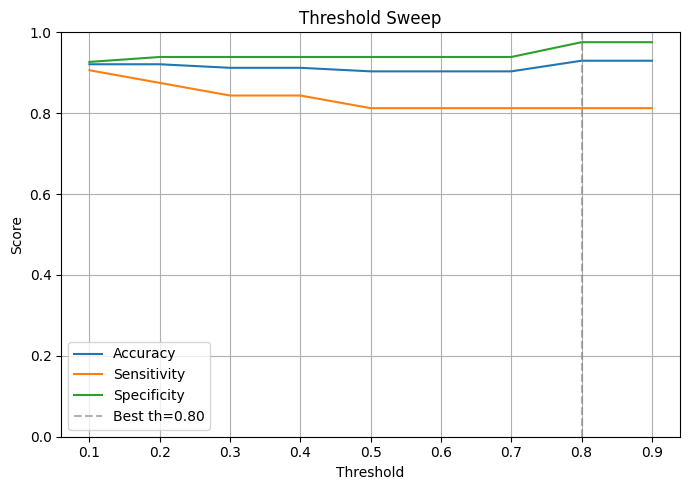

Saved plot to performance_evaluation\threshold_sweep_20251128_130616.png
Saved CSV to performance_evaluation\threshold_sweep_20251128_130616.csv


<Figure size 640x480 with 0 Axes>

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import os, datetime
import pandas as pd

def threshold_sweep(model, dataloader, thresholds=np.linspace(0.1, 0.9, 9), save=True):
    model.eval()
    rows = []
    for th in thresholds:
        tp = tn = fp = fn = 0
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)              # [B,2]
            y_j = y[:, 0].unsqueeze(1)    # jaundice label
            with torch.no_grad():
                logits_j, _ = model(x)
                probs_j = torch.sigmoid(logits_j)
                preds = (probs_j > th).int()
            tp += ((preds == 1) & (y_j == 1)).sum().item()
            tn += ((preds == 0) & (y_j == 0)).sum().item()
            fp += ((preds == 1) & (y_j == 0)).sum().item()
            fn += ((preds == 0) & (y_j == 1)).sum().item()
        acc = (tp + tn) / len(dataloader.dataset)
        sens = tp / (tp + fn + 1e-9)
        spec = tn / (tn + fp + 1e-9)
        rows.append({"threshold": th, "acc": acc, "sens": sens, "spec": spec})
        print(f"th={th:.2f} acc={acc:.3f} sens={sens:.3f} spec={spec:.3f}")

    df = pd.DataFrame(rows)
    best = df.loc[df["acc"].idxmax()]
    print(f"\nBest by acc: th={best.threshold:.2f} acc={best.acc:.3f} sens={best.sens:.3f} spec={best.spec:.3f}")

    # Plot
    plt.figure(figsize=(7, 5))
    plt.plot(df["threshold"], df["acc"], label="Accuracy")
    plt.plot(df["threshold"], df["sens"], label="Sensitivity")
    plt.plot(df["threshold"], df["spec"], label="Specificity")
    plt.axvline(best.threshold, color="gray", linestyle="--", alpha=0.6, label=f"Best th={best.threshold:.2f}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.title("Threshold Sweep")
    plt.tight_layout()
    plt.show()

    if save:
        out_dir = "performance_evaluation"
        os.makedirs(out_dir, exist_ok=True)
        ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        png_path = os.path.join(out_dir, f"threshold_sweep_{ts}.png")
        csv_path = os.path.join(out_dir, f"threshold_sweep_{ts}.csv")
        plt.savefig(png_path, bbox_inches="tight")
        df.to_csv(csv_path, index=False)
        print(f"Saved plot to {png_path}")
        print(f"Saved CSV to {csv_path}")
    return df, best

# Run the sweep
df_sweep, best_point = threshold_sweep(model, val_dl)


## 10. Comprehensive Performance Evaluation

**Purpose:** Generate detailed performance metrics and visualizations at the chosen threshold.

**What it does:**

- Uses the selected threshold (0.80) from previous analysis
- Collects predictions and probabilities on validation set
- Computes comprehensive metrics:
  - **Confusion Matrix:** True Positives, False Positives, True Negatives, False Negatives
  - **ROC Curve:** True Positive Rate vs False Positive Rate with AUC score
  - **Precision-Recall Curve:** Precision vs Recall with AUC score
  - **Classification metrics:** Accuracy, Sensitivity, Specificity
- **Generates 3-panel visualization:**
  1. ROC curve with AUC
  2. Precision-Recall curve with AUC
  3. Confusion matrix heatmap
- **Saves artifacts:**
  - Combined metrics plot
  - CSV with all performance statistics
  - Both saved to `performance_evaluation/` folder

**Output:** Complete performance analysis showing model quality and decision boundaries.


Threshold 0.80 -> acc=0.930 sens=0.812 spec=0.976
Confusion matrix [[tn, fp], [fn, tp]]:
[[80  2]
 [ 6 26]]


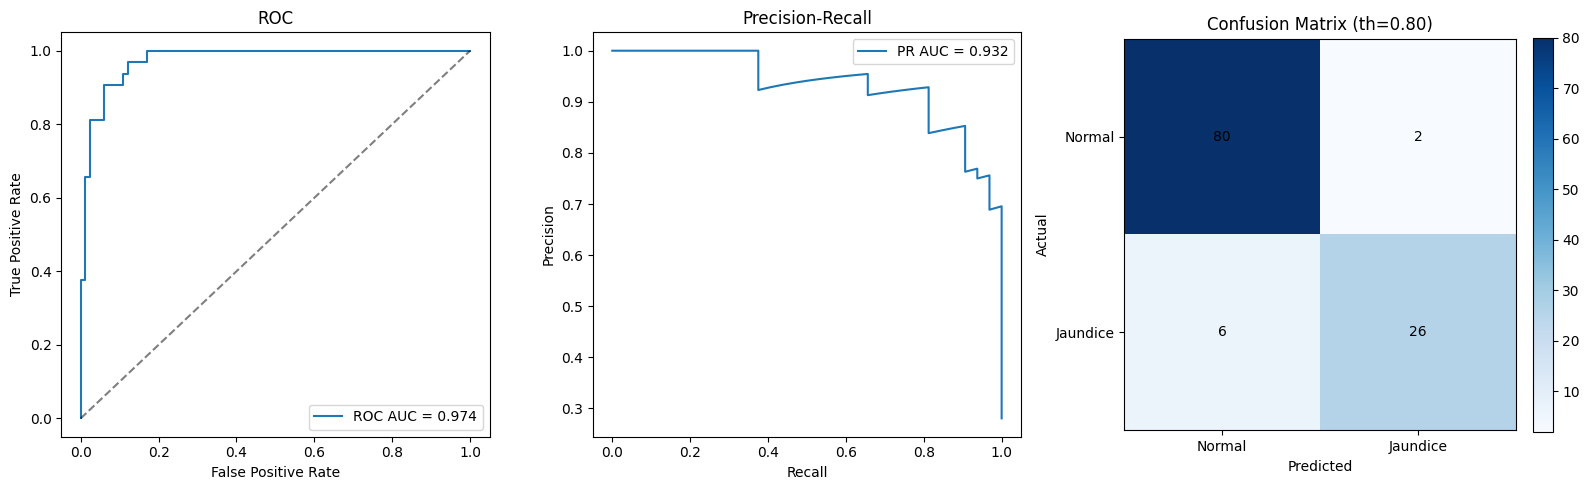

Saved plot to performance_evaluation\metrics_20251128_134906.png
Saved metrics to performance_evaluation\metrics_20251128_134906.csv


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
import os
import pandas as pd
import datetime

CHOSEN_TH = 0.80  # from your sweep

def collect_scores(model, dataloader, threshold):
    model.eval()
    all_probs = []
    all_labels = []
    all_preds = []
    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)  # [B,2]
        y_j = y[:, 0].unsqueeze(1)
        with torch.no_grad():
            logits_j, _ = model(x)
            probs_j = torch.sigmoid(logits_j)
        all_probs.extend(probs_j.cpu().numpy().ravel().tolist())
        all_labels.extend(y_j.cpu().numpy().ravel().tolist())
        preds = (probs_j > threshold).int()
        all_preds.extend(preds.cpu().numpy().ravel().tolist())
    return np.array(all_labels), np.array(all_probs), np.array(all_preds)

labels, probs, preds = collect_scores(model, val_dl, threshold=CHOSEN_TH)

# Confusion matrix and metrics
cm = confusion_matrix(labels, preds)
tn, fp, fn, tp = cm.ravel()
acc = (tp + tn) / (tp + tn + fp + fn)
sens = tp / (tp + fn + 1e-9)
spec = tn / (tn + fp + 1e-9)

# ROC and PR
fpr, tpr, _ = roc_curve(labels, probs)
roc_auc = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(labels, probs)
pr_auc = auc(rec, prec)

print(f"Threshold {CHOSEN_TH:.2f} -> acc={acc:.3f} sens={sens:.3f} spec={spec:.3f}")
print("Confusion matrix [[tn, fp], [fn, tp]]:")
print(cm)

# Make plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC")
axes[0].legend()

axes[1].plot(rec, prec, label=f"PR AUC = {pr_auc:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall")
axes[1].legend()

im = axes[2].imshow(cm, cmap="Blues")
axes[2].set_title(f"Confusion Matrix (th={CHOSEN_TH:.2f})")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
axes[2].set_xticks([0, 1]); axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(["Normal", "Jaundice"])
axes[2].set_yticklabels(["Normal", "Jaundice"])
for (i, j), v in np.ndenumerate(cm):
    axes[2].text(j, i, str(v), ha="center", va="center", color="black")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Save artifacts
out_dir = "performance_evaluation"
os.makedirs(out_dir, exist_ok=True)
ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
fig_path = os.path.join(out_dir, f"metrics_{ts}.png")
fig.savefig(fig_path, bbox_inches="tight")

metrics_csv = os.path.join(out_dir, f"metrics_{ts}.csv")
pd.DataFrame([{
    "threshold": CHOSEN_TH,
    "accuracy": acc,
    "sensitivity": sens,
    "specificity": spec,
    "roc_auc": roc_auc,
    "pr_auc": pr_auc,
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "tp": tp,
    "total": len(labels),
}]).to_csv(metrics_csv, index=False)

print(f"Saved plot to {fig_path}")
print(f"Saved metrics to {metrics_csv}")


## 11. Dual-Head Model Evaluation

**Purpose:** Evaluate both the jaundice detection and quality assessment heads simultaneously.

**What it does:**

- Runs inference on validation set using both model heads
- **Jaundice metrics:**
  - Accuracy, Sensitivity, Specificity
  - Confusion matrix statistics (TP, TN, FP, FN)
- **Quality metrics:**
  - Average quality probability across all images
  - Percentage of low-quality images (quality prob < 0.7)
  - Quality score distribution (mean, 10th percentile, 90th percentile)
- Uses threshold of 0.5 for binary predictions
- Includes progress bar for evaluation tracking

**Output:**

- Complete evaluation report showing performance of both detection tasks
- Quality statistics to understand lighting conditions in the dataset


In [18]:
# Simple evaluation using the 2-head model (no wrapper)
def evaluate_model(model, dataloader, quality_thresh=0.7):
    model.eval()
    tp = tn = fp = fn = 0
    low_quality = 0
    qual_probs = []

    for x, y in tqdm(dataloader, desc="Evaluating"):
        x = x.to(device)
        y = y.to(device)              # shape [B, 2]
        y_j = y[:, 0].unsqueeze(1)    # jaundice label

        with torch.no_grad():
            logits_j, logits_q = model(x)
            probs_j = torch.sigmoid(logits_j)
            probs_q = torch.sigmoid(logits_q)

        preds_j = (probs_j > 0.5).int()

        # Jaundice metrics
        tp += ((preds_j == 1) & (y_j == 1)).sum().item()
        tn += ((preds_j == 0) & (y_j == 0)).sum().item()
        fp += ((preds_j == 1) & (y_j == 0)).sum().item()
        fn += ((preds_j == 0) & (y_j == 1)).sum().item()

        # Quality stats
        qual_probs.extend(probs_q.squeeze(1).cpu().tolist())
        low_quality += (probs_q < quality_thresh).sum().item()

    n = len(dataloader.dataset)
    acc = (tp + tn) / n
    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    low_quality_pct = 100.0 * low_quality / n
    avg_quality = float(np.mean(qual_probs)) if qual_probs else 0.0

    return {
        "accuracy": acc,
        "sensitivity": sens,
        "specificity": spec,
        "low_quality_pct": low_quality_pct,
        "avg_quality": avg_quality,
        "total": n,
    }

# Run evaluation
print("Evaluating 2-head model (jaundice + quality)...")
results = evaluate_model(model, val_dl)

print(f"\nEvaluation Results (on {results['total']} validation images):")
print(f"  Accuracy:    {results['accuracy']:.4f}")
print(f"  Sensitivity: {results['sensitivity']:.4f}")
print(f"  Specificity: {results['specificity']:.4f}")
print(f"  Avg quality prob: {results['avg_quality']:.3f}")
print(f"  Low-quality (<0.7): {results['low_quality_pct']:.1f}%")


def quality_stats(model, dataloader):
    model.eval()
    qs = []
    for x, _ in dataloader:
        x = x.to(device)
        with torch.no_grad():
            _, logits_q = model(x)
            qs.extend(torch.sigmoid(logits_q).cpu().numpy().ravel().tolist())
    print(f"Quality prob: mean={np.mean(qs):.3f}, p10={np.percentile(qs,10):.3f}, p90={np.percentile(qs,90):.3f}")

quality_stats(model, val_dl)


Evaluating 2-head model (jaundice + quality)...


c:\Users\sahan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]


Evaluation Results (on 114 validation images):
  Accuracy:    0.9035
  Sensitivity: 0.8125
  Specificity: 0.9390
  Avg quality prob: 1.000
  Low-quality (<0.7): 0.0%
Quality prob: mean=1.000, p10=0.999, p90=1.000


## 12. Model Export and Deployment

**Purpose:** Save trained model in multiple formats for production deployment.

**What it does:**

- **PyTorch format (.pt):**
  - Saves model state_dict (weights only)
  - File: `jaundice_mobilenetv3_v4.pt`
  - Used for PyTorch inference
- **ONNX format (.onnx):**
  - Exports model to ONNX (Open Neural Network Exchange)
  - File: `jaundice_mobilenetv3_v4.onnx`
  - Has two outputs: `logits_j` (jaundice), `logits_q` (quality)
  - Uses opset version 17 for compatibility
  - Enables cross-platform deployment (ONNX Runtime, mobile, edge devices)
- **Configuration file (.pt):**
  - Saves preprocessing parameters (image size, normalization constants, quality threshold)
  - File: `jaundice_mobilenetv3_v4_config.pt`
  - Ensures consistent preprocessing during inference

**Output:** Three files ready for production deployment across different platforms.


In [21]:
%pip install onnx

# Save 2-head PyTorch weights
torch.save(model.state_dict(), "jaundice_mobilenetv3_v4.pt")
print("Saved 2-head model weights.")

# Export 2-head model to ONNX (two outputs: jaundice + quality)
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
torch.onnx.export(
    model,
    dummy_input,
    "jaundice_mobilenetv3_v4.onnx",
    input_names=["input"],
    output_names=["logits_j", "logits_q"],
    opset_version=17,
)
print("Exported 2-head model to ONNX format.")

# Optional: save a small config blob alongside the model (no wrapper/brightness)
model_config = {
    "img_size": IMG_SIZE,
    "mean": MEAN,
    "std": STD,
    # Can add a quality threshold you plan to use at inference time, e.g.:
    "quality_threshold": 0.8,
}
torch.save(model_config, "jaundice_mobilenetv3_v4_config.pt")
print("Saved model config (preprocess params).")

print("All models saved successfully!")



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\sahan\AppData\Local\Temp\ipykernel_21096\3941912870.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(



Saved 2-head model weights.
Exported 2-head model to ONNX format.
Saved model config (preprocess params).
All models saved successfully!
